# 🏥 HCR4 — Finetuning TrOCR sur Ordonnances Médicales

Ce notebook fine-tune le modèle **TrOCR** (Microsoft) sur votre dataset de crops d'ordonnances manuscrites.

**Format du dataset** : Chaque image (crop) contient **une seule ligne** de médicament, associée à son texte dans `annotations.csv`.

---

**Avant de commencer :**
1. Allez dans **Exécution > Modifier le type d'exécution > GPU (T4)**
2. Uploadez le fichier `hcr4_dataset.zip` dans le panneau Fichiers (à gauche)

---

## Étape 1 — Installation des dépendances

In [ ]:
!pip install -q transformers[torch] datasets evaluate jiwer Pillow scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 64.3 MB/s eta 0:00:00


## Étape 2 — Upload et décompression du dataset

**Option A** : Upload direct (exécutez la cellule ci-dessous, une fenêtre s'ouvrira pour choisir `hcr4_dataset.zip`)

**Option B** : Si vous avez déjà uploadé le fichier manuellement dans le panneau Fichiers, passez directement à la décompression.

In [ ]:
# Option A : Upload interactif
from google.colab import files
uploaded = files.upload()  # Sélectionnez hcr4_dataset.zip

Saving hcr4_dataset.zip to hcr4_dataset.zip


In [ ]:
# Décompression du dataset
!unzip -o hcr4_dataset.zip -d .

# Vérification
import os
n_images = len(os.listdir('dataset/images'))
print(f"\n✅ Dataset décompressé : {n_images} crops trouvés")
print(f"📄 Fichier CSV : {'dataset/annotations.csv' if os.path.exists('dataset/annotations.csv') else '❌ INTROUVABLE'}")

Archive:  hcr4_dataset.zip
   creating: ./dataset/images/
  inflating: ./dataset/images/28_b.jpeg  
  inflating: ./dataset/images/70_h.jpeg  
  inflating: ./dataset/images/12_c.jpeg  
  inflating: ./dataset/images/46_b.jpeg  
  inflating: ./dataset/images/48_a.jpeg  
  inflating: ./dataset/images/76_d.jpeg  
  inflating: ./dataset/images/81_a.jpeg  
  inflating: ./dataset/images/29_b.jpeg  
  inflating: ./dataset/images/55_c.jpeg  
  inflating: ./dataset/images/3_c.jpeg  
  inflating: ./dataset/images/99_b.jpeg  
  inflating: ./dataset/images/76_h.jpeg  
  inflating: ./dataset/images/13_c.jpeg  
  inflating: ./dataset/images/54_a.jpeg  
  inflating: ./dataset/images/48_b.jpeg  
  inflating: ./dataset/images/15_a.jpeg  
  inflating: ./dataset/images/34_b.jpeg  
  inflating: ./dataset/images/23_d.jpeg  
  inflating: ./dataset/images/52_b.jpeg  
  inflating: ./dataset/images/76_g.jpeg  
  inflating: ./dataset/images/32_b.jpeg  
  inflating: ./dataset/images/95_b.jpeg  
  inflating: ./data

## Étape 3 — Vérification du GPU

In [ ]:
import torch

if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"✅ GPU détecté : {gpu_name} ({gpu_mem:.1f} GB VRAM)")
else:
    print("⚠️ Aucun GPU détecté ! Allez dans Exécution > Modifier le type d'exécution > GPU")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"📌 Device utilisé : {device}")

✅ GPU détecté : Tesla T4 (15.6 GB VRAM)
📌 Device utilisé : cuda


## Étape 4 — Chargement du modèle TrOCR et du processeur

In [ ]:
from transformers import TrOCRProcessor, VisionEncoderDecoderModel

MODEL_NAME = "microsoft/trocr-base-handwritten"
MAX_TARGET_LENGTH = 128  # Chaque crop = 1 seul médicament (texte court)

print(f"📥 Chargement de {MODEL_NAME}...")
processor = TrOCRProcessor.from_pretrained(MODEL_NAME)
model = VisionEncoderDecoderModel.from_pretrained(MODEL_NAME)

# Configuration du décodeur (ces paramètres restent sur model.config car ils concernent la configuration du modèle)
model.config.decoder_start_token_id = processor.tokenizer.cls_token_id
model.config.pad_token_id = processor.tokenizer.pad_token_id
model.config.vocab_size = model.config.decoder.vocab_size
model.config.eos_token_id = processor.tokenizer.sep_token_id

# Configuration des paramètres de génération (doivent être sur model.generation_config)
model.generation_config.max_length = MAX_TARGET_LENGTH
model.generation_config.early_stopping = True
model.generation_config.no_repeat_ngram_size = 3
model.generation_config.length_penalty = 2.0
model.generation_config.num_beams = 4

model.to(device)
print(f"✅ Modèle chargé sur {device}")

📥 Chargement de microsoft/trocr-base-handwritten...


Loading weights:   0%|          | 0/478 [00:00<?, ?it/s]

[transformers] VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-handwritten
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.bias   | MISSING | 
encoder.pooler.dense.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Modèle chargé sur cuda


## Étape 5 — Préparation du Dataset PyTorch

In [ ]:
import pandas as pd
from torch.utils.data import Dataset
from PIL import Image

class PrescriptionDataset(Dataset):
    """Dataset PyTorch pour crops d'ordonnances HCR4.

    Chaque image (crop) contient une seule ligne de médicament.
    """

    def __init__(self, csv_file, root_dir, processor, max_target_length=128):
        raw_df = pd.read_csv(csv_file)
        self.df = raw_df.drop_duplicates(subset='file_name', keep='last').reset_index(drop=True)
        self.root_dir = root_dir
        self.processor = processor
        self.max_target_length = max_target_length

        # Vérification des images manquantes
        missing = [f for f in self.df['file_name'] if not os.path.isfile(os.path.join(root_dir, str(f)))]
        if missing:
            print(f"⚠️ {len(missing)} image(s) manquante(s) : {missing[:5]}")

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        file_name = str(row['file_name'])
        text = str(row['text']).strip()

        image_path = os.path.join(self.root_dir, file_name)
        try:
            image = Image.open(image_path).convert('RGB')
        except Exception:
            image = Image.new('RGB', (384, 384))

        pixel_values = self.processor(image, return_tensors='pt').pixel_values

        labels = self.processor.tokenizer(
            text, padding='max_length',
            max_length=self.max_target_length, truncation=True
        ).input_ids
        labels = [l if l != self.processor.tokenizer.pad_token_id else -100 for l in labels]

        return {
            'pixel_values': pixel_values.squeeze(),
            'labels': torch.tensor(labels)
        }

print("✅ Classe PrescriptionDataset définie.")

✅ Classe PrescriptionDataset définie.


In [ ]:
# Utilisation des splits pré-générés pour éviter le Data Leakage des augmentations
import os

TRAIN_CSV = 'dataset/_train_split.csv'
EVAL_CSV = 'dataset/_eval_split.csv'
IMAGES_DIR = 'dataset/images'

train_dataset = PrescriptionDataset(TRAIN_CSV, IMAGES_DIR, processor, MAX_TARGET_LENGTH)
eval_dataset = PrescriptionDataset(EVAL_CSV, IMAGES_DIR, processor, MAX_TARGET_LENGTH)

print(f'🏋️ Entraînement : {len(train_dataset)} crops')
print(f'🧪 Évaluation   : {len(eval_dataset)} crops')


📊 Total de crops uniques : 335
🏋️ Entraînement : 284 crops
🧪 Évaluation   : 51 crops


## Étape 6 — Configuration et lancement de l'entraînement

In [ ]:
import evaluate

cer_metric = evaluate.load('cer')
wer_metric = evaluate.load('wer')

def compute_metrics(pred):
    """Calcule le WER (Word Error Rate) et le CER (Character Error Rate).

    WER = métrique principale : mesure si les noms de médicaments
          sont correctement reconnus mot par mot.
    CER = métrique secondaire : diagnostic au niveau caractère.
    """
    labels_ids = pred.label_ids
    pred_ids = pred.predictions

    # Remplacer -100 par pad_token_id
    labels_ids[labels_ids == -100] = processor.tokenizer.pad_token_id

    pred_str = processor.batch_decode(pred_ids, skip_special_tokens=True)
    label_str = processor.batch_decode(labels_ids, skip_special_tokens=True)

    wer = wer_metric.compute(predictions=pred_str, references=label_str)
    cer = cer_metric.compute(predictions=pred_str, references=label_str)
    return {'wer': wer, 'cer': cer}

print("✅ Métriques WER + CER prêtes.")

✅ Métriques WER + CER prêtes.


In [ ]:
from transformers import Seq2SeqTrainer, Seq2SeqTrainingArguments, default_data_collator

# ============================
# HYPER-PARAMETRES (AJUSTÉS POUR ÉVITER OOM)
# ============================
NUM_EPOCHS = 12
BATCH_SIZE = 4             # Réduit de 16 à 4 pour économiser la VRAM
LEARNING_RATE = 3e-5
GRADIENT_ACCUMULATION = 8  # 4 * 8 = 32 (on garde le même batch effectif)

training_args = Seq2SeqTrainingArguments(
    output_dir="./checkpoints",
    predict_with_generate=True,
    eval_strategy="epoch",
    save_strategy="epoch",
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION,
    learning_rate=LEARNING_RATE,
    weight_decay=0.05,
    num_train_epochs=NUM_EPOCHS,
    fp16=torch.cuda.is_available(),
    logging_steps=10,
    save_total_limit=3,
    load_best_model_at_end=True,
    metric_for_best_model="cer",
    greater_is_better=False,
    report_to="none",
    dataloader_num_workers=2,
    remove_unused_columns=False,
    warmup_ratio=0.1,
)

trainer = Seq2SeqTrainer(
    model=model,
    processing_class=processor,
    args=training_args,
    compute_metrics=compute_metrics,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    data_collator=default_data_collator,
)

print(f"🚀 Prêt avec paramètres optimisés ! Batch effectif = {BATCH_SIZE * GRADIENT_ACCUMULATION}")

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


🚀 Prêt avec paramètres optimisés ! Batch effectif = 32


In [ ]:
# Nettoyage de la mémoire avant de lancer
import torch
torch.cuda.empty_cache()

# ============================
# LANCEMENT DE L'ENTRAÎNEMENT
# ============================
print("🏋️ Entraînement en cours (optimisé pour la mémoire)...")
trainer.train()
print("\n✅ Entraînement terminé !")

🏋️ Entraînement en cours (optimisé pour la mémoire)...


Epoch,Training Loss,Validation Loss,Wer,Cer
1,No log,4.011119,0.958333,0.793548
2,67.452350,2.676326,0.979167,0.577419
3,17.101202,2.298659,0.916667,0.616129
4,9.427229,2.106772,0.770833,0.485484
5,4.172200,2.036885,0.739583,0.464516
6,2.132566,2.048197,0.697917,0.459677
7,1.430063,2.023662,0.718750,0.445161
8,0.847207,2.138916,0.687500,0.435484
9,0.670765,2.130313,0.666667,0.429032
10,0.432324,2.217473,0.687500,0.411290


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['encoder.layers.0.attention.q_proj.weight', 'encoder.layers.0.attention.k_proj.weight', 'encoder.layers.0.attention.v_proj.weight', 'encoder.layers.0.attention.o_proj.weight', 'encoder.layers.0.attention.o_proj.bias', 'encoder.layers.0.layernorm_before.weight', 'encoder.layers.0.layernorm_before.bias', 'encoder.layers.0.layernorm_after.weight', 'encoder.layers.0.layernorm_after.bias', 'encoder.layers.0.mlp.fc1.weight', 'encoder.layers.0.mlp.fc1.bias', 'encoder.layers.0.mlp.fc2.weight', 'encoder.layers.0.mlp.fc2.bias', 'encoder.layers.1.attention.q_proj.weight', 'encoder.layers.1.attention.k_proj.weight', 'encoder.layers.1.attention.v_proj.weight', 'encoder.layers.1.attention.o_proj.weight', 'encoder.layers.1.attention.o_proj.bias', 'encoder.layers.1.layernorm_before.weight', 'encoder.layers.1.layernorm_before.bias', 'encoder.layers.1.layernorm_after.weight', 'encoder.layers.1.layernorm_after.bias', 'encoder.layers.


✅ Entraînement terminé !


## Étape 7 — Sauvegarde du modèle fine-tuné

In [ ]:
FINAL_DIR = './trocr_finetuned_hcr4'

trainer.save_model(FINAL_DIR)
processor.save_pretrained(FINAL_DIR)

print(f"💾 Modèle sauvegardé dans : {FINAL_DIR}")

# Lister les fichiers sauvegardés
for f in os.listdir(FINAL_DIR):
    size = os.path.getsize(os.path.join(FINAL_DIR, f)) / 1e6
    print(f"   {f} ({size:.1f} MB)")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

💾 Modèle sauvegardé dans : ./trocr_finetuned_hcr4
   tokenizer_config.json (0.0 MB)
   model.safetensors (1335.7 MB)
   config.json (0.0 MB)
   training_args.bin (0.0 MB)
   processor_config.json (0.0 MB)
   generation_config.json (0.0 MB)
   tokenizer.json (3.6 MB)


## Étape 8 — Test du modèle fine-tuné

Loading weights:   0%|          | 0/480 [00:00<?, ?it/s]

TEST DU MODÈLE FINE-TUNÉ

📸 9_b.jpeg  ❌
   Attendu : Escodyne cp
   Prédit  : Escodyne comprimé

📸 36_b.jpeg  ❌
   Attendu : efferalagan 1g
   Prédit  : Efferalgan sirop

📸 24_e.jpeg  ❌
   Attendu : Dycinone injectable
   Prédit  : Dyninone vit

📸 62_a.jpeg  ✅
   Attendu : Almax forte
   Prédit  : Almax forte

📸 18_a.jpeg  ✅
   Attendu : Miorel
   Prédit  : Miorel

📸 77_d.jpeg  ❌
   Attendu : Zocin
   Prédit  : Zocin sp

📸 57_c.jpeg  ✅
   Attendu : Magnoral
   Prédit  : Magnoral

📸 57_b.jpeg  ❌
   Attendu : Genset
   Prédit  : Genset 10mg


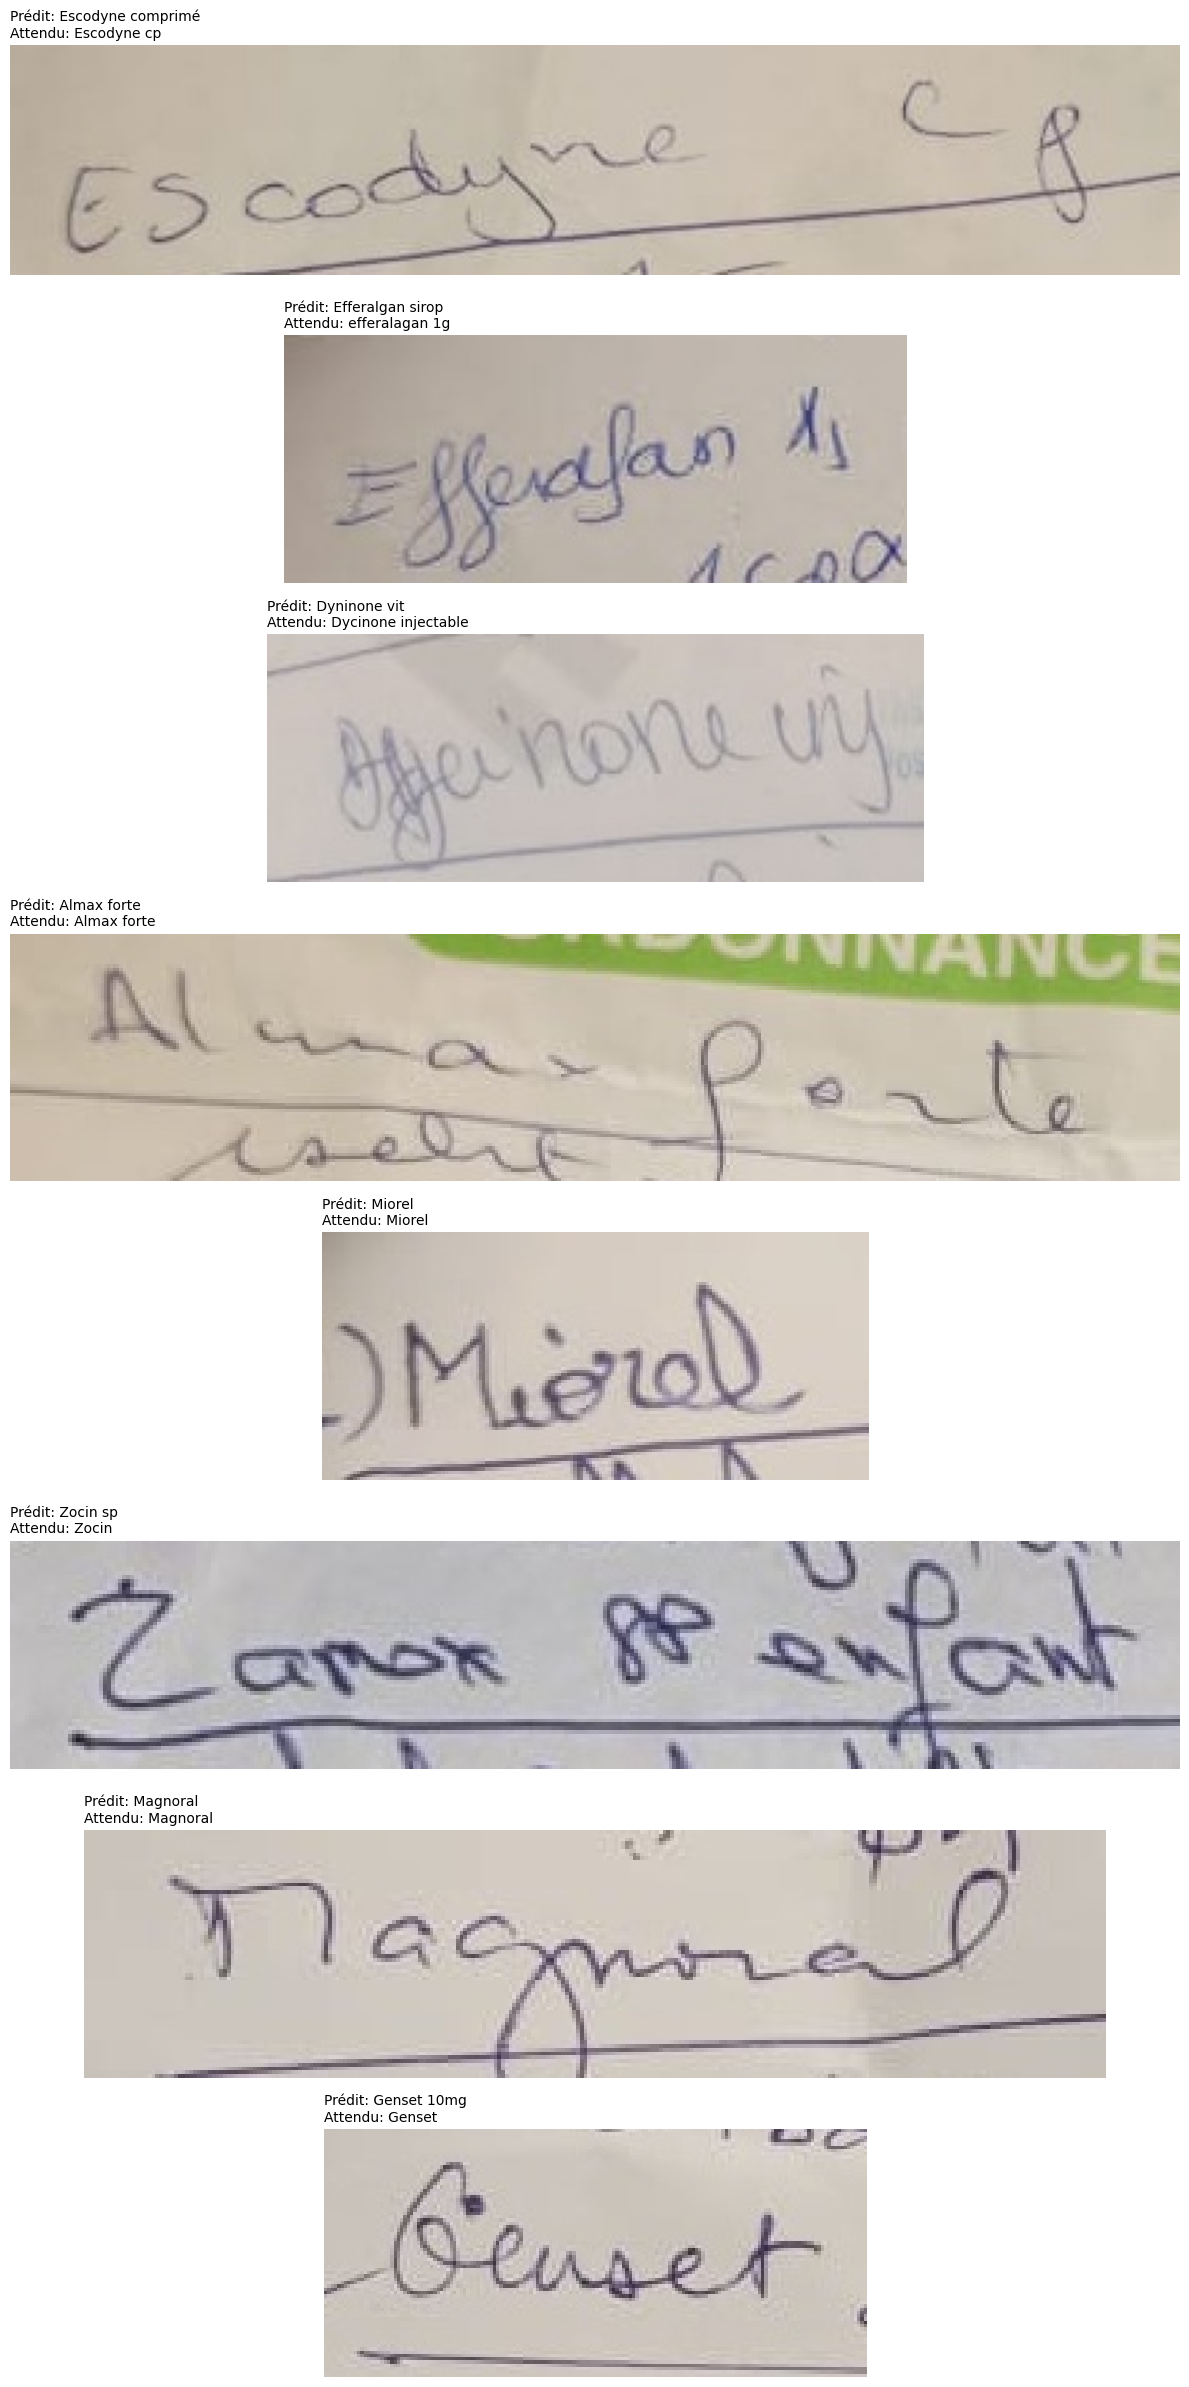

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

# Charger le modèle finetuné
finetuned_model = VisionEncoderDecoderModel.from_pretrained(FINAL_DIR).to(device)
finetuned_processor = TrOCRProcessor.from_pretrained(FINAL_DIR)

# Tester sur quelques crops du jeu d'évaluation
test_df = pd.read_csv('dataset/eval.csv').drop_duplicates(subset='file_name', keep='last').head(8)

print("=" * 70)
print("TEST DU MODÈLE FINE-TUNÉ")
print("=" * 70)

fig, axes = plt.subplots(len(test_df), 1, figsize=(12, 3 * len(test_df)))
if len(test_df) == 1:
    axes = [axes]

for i, (_, row) in enumerate(test_df.iterrows()):
    img_path = os.path.join(IMAGES_DIR, str(row['file_name']))
    image = Image.open(img_path).convert('RGB')

    pixel_values = finetuned_processor(image, return_tensors='pt').pixel_values.to(device)
    generated_ids = finetuned_model.generate(pixel_values)
    prediction = finetuned_processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

    # Texte attendu (une seule ligne par crop)
    expected = str(row['text']).strip()

    axes[i].imshow(image)
    axes[i].set_title(f"Prédit: {prediction}\nAttendu: {expected}", fontsize=10, loc='left')
    axes[i].axis('off')

    match = '✅' if prediction.lower().strip() == expected.lower().strip() else '❌'
    print(f"\n📸 {row['file_name']}  {match}")
    print(f"   Attendu : {expected}")
    print(f"   Prédit  : {prediction}")

plt.tight_layout()
plt.show()

## Étape 9 — Télécharger le modèle sur votre machine

Le modèle sera compressé en ZIP puis téléchargé automatiquement. Vous devrez ensuite le décompresser dans votre projet HCR4.

In [ ]:
# Compression du modèle
!zip -r trocr_finetuned_hcr4.zip trocr_finetuned_hcr4/

# Téléchargement automatique
from google.colab import files
files.download('trocr_finetuned_hcr4.zip')

print("\n" + "=" * 60)
print("📦 Téléchargement lancé !")
print("")
print("Pour utiliser ce modèle dans HCR4 :")
print("  1. Décompressez le ZIP dans : backend/ai/finetuning/")
print("  2. Modifiez backend/config.py :")
print('     HTR_MODEL_NAME = "backend/ai/finetuning/trocr_finetuned_hcr4"')
print("  3. Relancez l'application : python run.py")
print("=" * 60)

  adding: trocr_finetuned_hcr4/ (stored 0%)
  adding: trocr_finetuned_hcr4/tokenizer_config.json (deflated 51%)
  adding: trocr_finetuned_hcr4/model.safetensors (deflated 7%)
  adding: trocr_finetuned_hcr4/config.json (deflated 74%)
  adding: trocr_finetuned_hcr4/training_args.bin (deflated 53%)
  adding: trocr_finetuned_hcr4/processor_config.json (deflated 53%)
  adding: trocr_finetuned_hcr4/generation_config.json (deflated 58%)
  adding: trocr_finetuned_hcr4/tokenizer.json (deflated 82%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


📦 Téléchargement lancé !

Pour utiliser ce modèle dans HCR4 :
  1. Décompressez le ZIP dans : backend/ai/finetuning/
  2. Modifiez backend/config.py :
     HTR_MODEL_NAME = "backend/ai/finetuning/trocr_finetuned_hcr4"
  3. Relancez l'application : python run.py
